In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('/content/Mall_Customers.csv')

In [3]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df1= df.drop(columns=['CustomerID', 'Age', 'Genre'], axis=1)

In [7]:
df1

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [8]:
#outlier removal
idx= df1.loc[df1['Annual Income (k$)'] >110].index
print(idx)
df1.drop(idx, inplace= True)

Index([192, 193, 194, 195, 196, 197, 198, 199], dtype='int64')


Text(0, 0.5, 'Spending Score (1-100)')

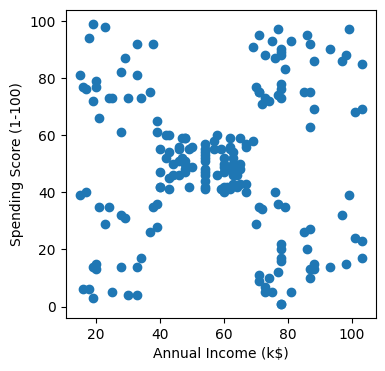

In [9]:
plt.figure(figsize= (4,4))
plt.scatter(data= df1, x= 'Annual Income (k$)', y= 'Spending Score (1-100)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
# plt.show()

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(df1,df1, test_size= 0.2, random_state=24)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((153, 2), (39, 2), (153, 2), (39, 2))

# **Kmeans Clustering**

In [11]:
from sklearn.cluster import KMeans
wcss= []
for i in range(1,11):
  kmeans= KMeans(n_clusters= i, init= 'k-means++')
  kmeans.fit(x_train)
  wcss.append(kmeans.inertia_)
wcss

[176232.01307189543,
 114851.88282586391,
 91992.04025527737,
 53074.63893566696,
 24880.342792145606,
 20838.02398277299,
 20099.37863247864,
 15900.389519140992,
 15182.721870428419,
 13968.943308434486]

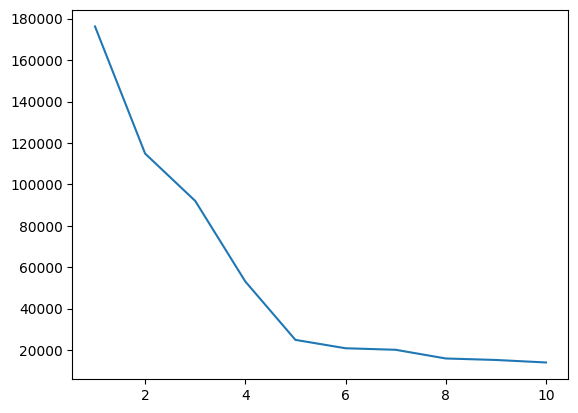

In [12]:
plt.plot(range(1,11), wcss)

In [13]:
!pip install kneed

In [14]:
from kneed import KneeLocator
kl= KneeLocator(range(1,11), wcss, curve= 'convex', direction= 'decreasing')
kl.knee

np.int64(5)

In [15]:
from sklearn.cluster import KMeans
kmean= KMeans(n_clusters= 5)
kmean.fit(x_train)


KMeans(n_clusters=5)

In [16]:
centroids= kmean.cluster_centers_
centroids.shape

(5, 2)

In [17]:
centroids

array([[26.94736842, 77.        ],
       [81.62068966, 82.24137931],
       [83.72727273, 18.5       ],
       [55.5625    , 48.890625  ],
       [27.42105263, 19.05263158]])

In [18]:
centroids[:,0], centroids[:,1]

(array([26.94736842, 81.62068966, 83.72727273, 55.5625    , 27.42105263]),
 array([77.        , 82.24137931, 18.5       , 48.890625  , 19.05263158]))

In [19]:
y_labels=kmean.labels_
y_labels.shape

(153,)

Text(0, 0.5, 'Spending Score (1-100)')

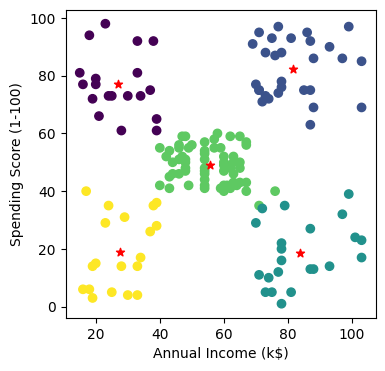

In [20]:
plt.figure(figsize= (4,4))
plt.scatter(data= x_train, x= 'Annual Income (k$)', y= 'Spending Score (1-100)', c= y_labels)
plt.scatter(x=centroids[:,0], y=centroids[:,1], marker= '*', color= 'red')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
# plt.show()

In [21]:
y_test_labels= kmean.fit_predict(x_test)
y_test_labels.shape

(39,)

Text(0, 0.5, 'Spending Score (1-100)')

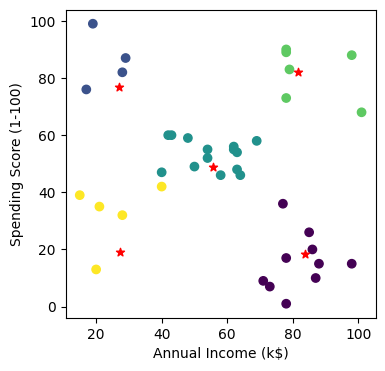

In [22]:
plt.figure(figsize= (4,4))
plt.scatter(data= x_test, x= 'Annual Income (k$)', y= 'Spending Score (1-100)', c= y_test_labels)
plt.scatter(x=centroids[:,0], y=centroids[:,1], marker= '*', color= 'red')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
# plt.show()

In [23]:
from sklearn.metrics import silhouette_score
sillhoutte_coff= []
for i in range(2,11):
  kmeans= KMeans(n_clusters=i, init= 'k-means++')
  kmeans.fit(x_train)
  score= silhouette_score(x_train, kmeans.labels_, metric= 'euclidean')
  sillhoutte_coff.append(score)
sillhoutte_coff

[np.float64(0.39933162710038544),
 np.float64(0.417111218224035),
 np.float64(0.4977124347035743),
 np.float64(0.5669632135608828),
 np.float64(0.4690141166537071),
 np.float64(0.46129302071282596),
 np.float64(0.44119944752917495),
 np.float64(0.4068620933691577),
 np.float64(0.4197016503346484)]

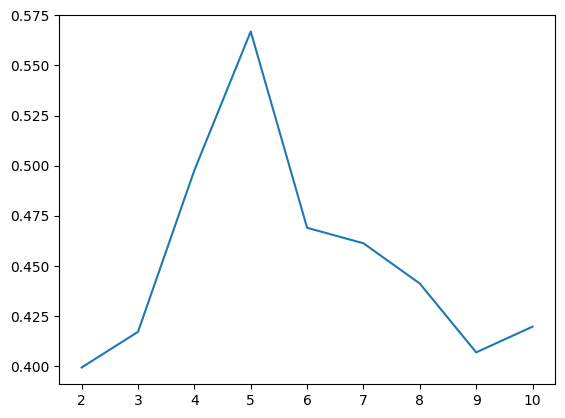

In [24]:
plt.plot(range(2,11), sillhoutte_coff)

# **Hierarical Clustering**

In [25]:
from sklearn import datasets

In [26]:
iris= datasets.load_iris()
df_iris= pd.DataFrame(iris.data)
df_iris.columns= iris.feature_names
df_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


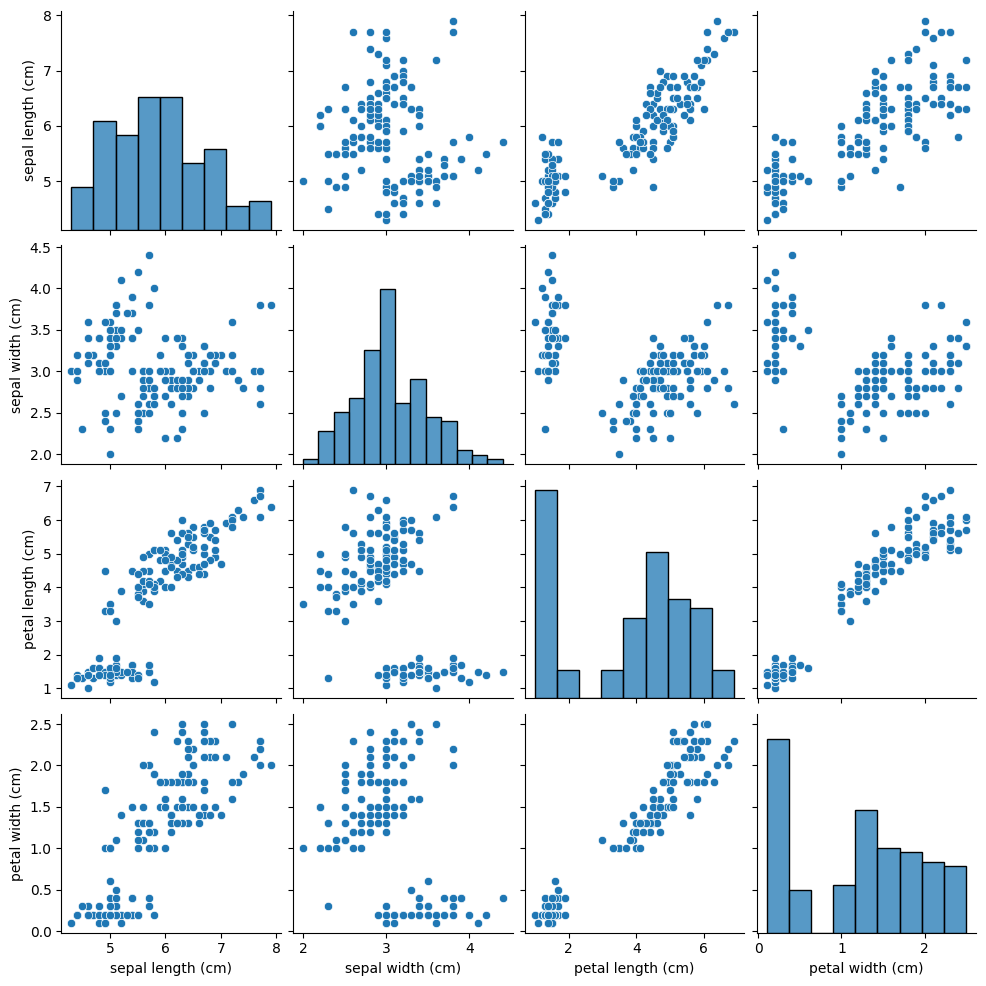

In [27]:
sns.pairplot(df_iris)

In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test= train_test_split(df_iris, test_size= 0.2, random_state=24)
x_train.shape, x_test.shape

((120, 4), (30, 4))

In [29]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
x_train= sc.fit_transform(x_train)
x_test= sc.transform(x_test)

<Axes: >

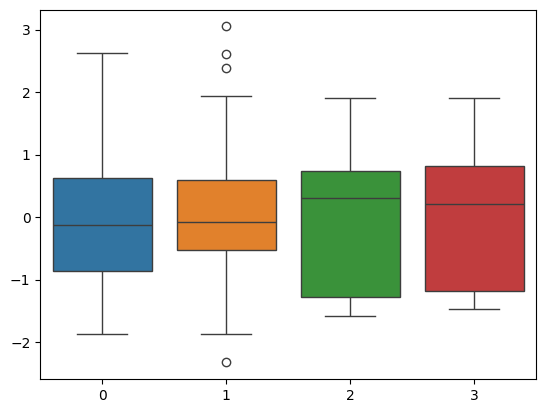

In [30]:
sns.boxplot(x_train)

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [35.0, 35.0, 45.0, 45.0],
  [55.0, 55.0, 65.0, 65.0],
  [40.0, 40.0, 60.0, 60.0],
  [12.5, 12.5, 50.0, 50.0],
  [85.0, 85.0, 95.0, 95.0],
  [75.0, 75.0, 90.0, 90.0],
  [31.25, 31.25, 82.5, 82.5],
  [115.0, 115.0, 125.0, 125.0],
  [145.0, 145.0, 155.0, 155.0],
  [135.0, 135.0, 150.0, 150.0],
  [120.0, 120.0, 142.5, 142.5],
  [105.0, 105.0, 131.25, 131.25],
  [175.0, 175.0, 185.0, 185.0],
  [165.0, 165.0, 180.0, 180.0],
  [215.0, 215.0, 225.0, 225.0],
  [205.0, 205.0, 220.0, 220.0],
  [195.0, 195.0, 212.5, 212.5],
  [172.5, 172.5, 203.75, 203.75],
  [118.125, 118.125, 188.125, 188.125],
  [235.0, 235.0, 245.0, 245.0],
  [265.0, 265.0, 275.0, 275.0],
  [255.0, 255.0, 270.0, 270.0],
  [240.0, 240.0, 262.5, 262.5],
  [285.0, 285.0, 295.0, 295.0],
  [305.0, 305.0, 315.0, 315.0],
  [335.0, 335.0, 345.0, 345.0],
  [325.0, 325.0, 340.0, 340.0],
  [355.0, 355.0, 365.0, 365.0],
  [375.0, 375.0, 385.0, 385.0],
  [360.0, 360.0, 380.0

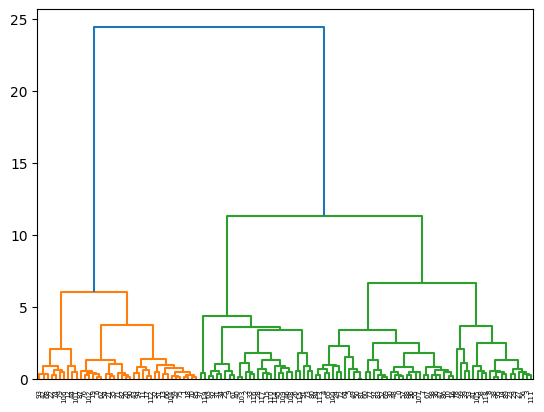

In [31]:
from scipy.cluster.hierarchy import dendrogram, linkage
dendrogram(linkage(x_train, method= 'ward'))


In [32]:
from sklearn.cluster import AgglomerativeClustering
agglo= AgglomerativeClustering(n_clusters= 2)
agglo.fit(x_train)
y_train_labels= agglo.labels_


In [33]:
silhouette_score(x_train, y_train_labels, metric= 'euclidean')

np.float64(0.5819845301051465)

In [34]:
x_train.shape

(120, 4)

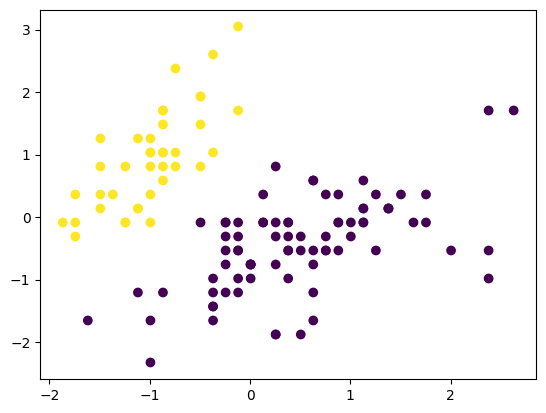

In [35]:
plt.scatter(x=x_train[:,0],y= x_train[:,1], c=y_train_labels)

# **DBSCAN**

In [36]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [37]:
X,Y= make_moons(n_samples= 400, noise= 0.05)
X.shape, Y.shape

((400, 2), (400,))

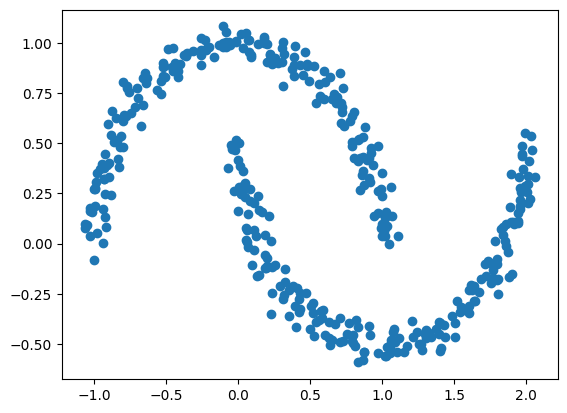

In [38]:
plt.scatter(x= X[:,0], y= X[:,1])

In [39]:
X_scaled= StandardScaler().fit_transform(X)

In [40]:
dbscan= DBSCAN(eps= 0.5, min_samples=5)
dbscan.fit(X_scaled)
y_labels= dbscan.labels_

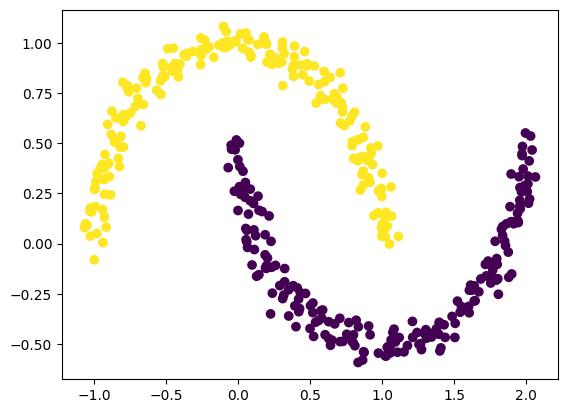

In [41]:
plt.scatter(x= X[:,0], y= X[:,1], c= y_labels)

In [42]:
from sklearn.metrics import silhouette_score
silhouette_score(X_scaled, y_labels, metric= 'euclidean')

np.float64(0.38835759775603507)

# **K-Mediods Clustering**

In [46]:
!pip install scikit_learn_extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 10.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit_learn_extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=1959515 sha256=c70cba43527cd1428bc2bfbe322c77d61d0903ac19d8e0f54fa7759e1aac6518
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit_learn_extra
